In [1]:
import ksmesopy.core as meso
import matplotlib.pyplot as plt

In [1]:
!pip install git+https://github.com/soilwater/ksmesopy.git

  Cloning https://github.com/soilwater/ksmesopy.git to c:\users\andrespatrignani\appdata\local\temp\pip-req-build-ijaowemz
  Resolved https://github.com/soilwater/ksmesopy.git to commit fa35c71098d1954b38349042ad5330d99424d168
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/soilwater/ksmesopy.git 'C:\Users\andrespatrignani\AppData\Local\Temp\pip-req-build-ijaowemz'
ERROR: Exception:
Traceback (most recent call last):
  File "D:\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 71, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_internal\commands\install.py", line 393, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 79, in resolve
    collec

In [2]:
station = "Manhattan"
start_date = "2017-01-01 01:00:00"
end_date = "2025-12-01 00:00:00"
interval = "hour"
"""
variables = ["TEMP2MAVG","RELHUM2MAVG","SRAVG","WSPD2MAVG","PRECIP",
             "SOILKA5CM","SOILKA10CM","SOILKA20CM","SOILKA50CM",
             "SOILEC5CM","SOILEC10CM","SOILEC20CM","SOILEC50CM",
             "SOILTMP5AVG655","SOILTMP10AVG655","SOILTMP20AVG655","SOILTMP50AVG655"]
"""
variables = ["TEMP2MAVG","RELHUM2MAVG","SRAVG","WSPD2MAVG","PRECIP"]
df = meso.request_data(station,start_date,end_date,interval,variables)

Requesting 2017-01-01 01:00:00 to 2017-05-06 01:00:00
Requesting 2017-05-06 02:00:00 to 2017-09-08 02:00:00
Requesting 2017-09-08 03:00:00 to 2018-01-11 03:00:00
Requesting 2018-01-11 04:00:00 to 2018-05-16 04:00:00
Requesting 2018-05-16 05:00:00 to 2018-09-18 05:00:00
Requesting 2018-09-18 06:00:00 to 2019-01-21 06:00:00
Requesting 2019-01-21 07:00:00 to 2019-05-26 07:00:00
Requesting 2019-05-26 08:00:00 to 2019-09-28 08:00:00
Requesting 2019-09-28 09:00:00 to 2020-01-31 09:00:00
Requesting 2020-01-31 10:00:00 to 2020-06-04 10:00:00
Requesting 2020-06-04 11:00:00 to 2020-10-07 11:00:00
Requesting 2020-10-07 12:00:00 to 2021-02-09 12:00:00
Requesting 2021-02-09 13:00:00 to 2021-06-14 13:00:00
Requesting 2021-06-14 14:00:00 to 2021-10-17 14:00:00
Requesting 2021-10-17 15:00:00 to 2022-02-19 15:00:00
Requesting 2022-02-19 16:00:00 to 2022-06-24 16:00:00
Requesting 2022-06-24 17:00:00 to 2022-10-27 17:00:00
Requesting 2022-10-27 18:00:00 to 2023-03-01 18:00:00
Requesting 2023-03-01 19:00:

In [3]:
df = meso.rename_using_preset(df)

In [5]:
df['srad'] = meso.srad_to_mj(df['srad'], period=3600)

In [7]:
df.head()

,time,temp,rhum,srad,wspd,prcp
0,2017-01-01 01:00:00,-5.51,88.37,0.000000,0.79,0.0
1,2017-01-01 02:00:00,-6.30,88.10,0.000000,0.57,0.0
2,2017-01-01 03:00:00,-6.35,90.57,0.000000,0.37,0.0
3,2017-01-01 04:00:00,-6.66,90.58,0.000036,0.48,0.0
4,2017-01-01 05:00:00,-6.33,89.48,0.000036,0.65,0.0


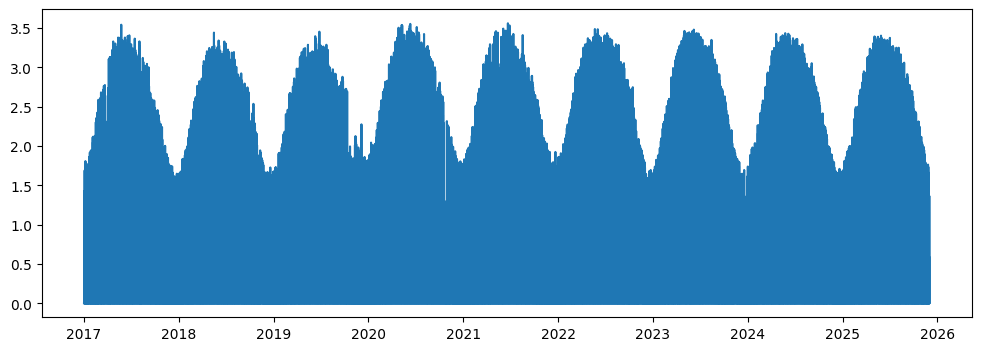

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df['time'], df['srad'])

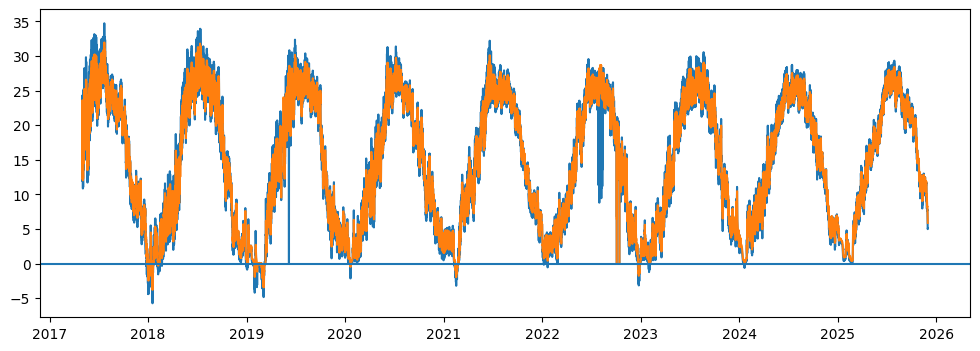

In [11]:
plt.figure(figsize=(12,4))
plt.plot(df['time'], df['soil_temp_5cm'])
plt.plot(df['time'], df['soil_temp_10cm'])
plt.axhline(0)

In [9]:
df.to_csv(f"{station.lower().replace(" ","_")}.csv", index=False)